In [32]:

# CORE LIBRARIES
import os
import zipfile
import random
import numpy as np

# VISUALIZATION
import matplotlib.pyplot as plt
import seaborn as sns

#  IMAGE PROCESSING
import cv2
from PIL import Image

# DATA HANDLING
import pandas as pd

# TENSORFLOW / KERAS
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# EVALUATION METRICS
from sklearn.metrics import confusion_matrix, classification_report,roc_curve, auc

# REPRODUCIBILITY (IMPORTANT)
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [11]:
from google.colab import drive

# Mount Google Drive (force_remount avoids errors if rerun)
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [12]:
# Path to your zip file
zip_path = '/content/drive/MyDrive/archive.zip'

# Destination folder in Colab (temporary, fast)
local_extract_path = '/content/malaria_data'

# Create folder if not exists
os.makedirs(local_extract_path, exist_ok=True)

# Extract ONLY if not already extracted (prevents re-extraction every run)
if not os.listdir(local_extract_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(local_extract_path)
    print("Extraction complete!")
else:
    print("Data already extracted. Skipping extraction.")

# Show contents
print("Extracted files/folders:", os.listdir(local_extract_path))

Data already extracted. Skipping extraction.
Extracted files/folders: ['cell_images']


In [13]:

# Root extracted path
root_path = '/content/malaria_data'

# Auto-detect actual dataset folder
possible_path = os.path.join(root_path, 'cell_images')

# Some zips have nested folder (cell_images/cell_images)
if os.path.exists(os.path.join(possible_path, 'Parasitized')):
    base_path = possible_path
else:
    base_path = os.path.join(possible_path, 'cell_images')

print(f"Using dataset path: {base_path}\n")

# Verify classes and count images safely
classes = ['Parasitized', 'Uninfected']

for folder in classes:
    folder_path = os.path.join(base_path, folder)

    if os.path.exists(folder_path):
        num_images = len(os.listdir(folder_path))
        print(f"{folder}: {num_images} images")
    else:
        print(f"Warning: {folder} folder not found!")


Using dataset path: /content/malaria_data/cell_images

Parasitized: 13780 images
Uninfected: 13780 images


/tmp/ipykernel_1539/3204394187.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Class', y='Count', data=df, palette='viridis')


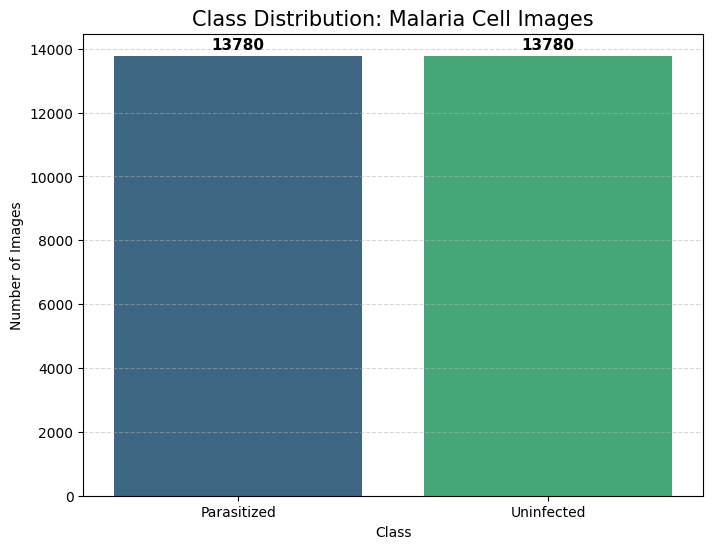

Imbalance Ratio: 1.00 (1.0 = perfectly balanced)


In [14]:
# 1. Collect counts safely
classes = ['Parasitized', 'Uninfected']
data_counts = {}

for cls in classes:
    folder_path = os.path.join(base_path, cls)
    data_counts[cls] = len(os.listdir(folder_path))

# 2. Convert to DataFrame
df = pd.DataFrame(list(data_counts.items()), columns=['Class', 'Count'])

# 3. Plot
plt.figure(figsize=(8, 6))
ax = sns.barplot(x='Class', y='Count', data=df, palette='viridis')

# Add labels on bars
for p in ax.patches:
    height = int(p.get_height())
    ax.annotate(f'{height}',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='center',
                xytext=(0, 8),
                textcoords='offset points',
                fontsize=11, fontweight='bold')

# Formatting
plt.title('Class Distribution: Malaria Cell Images', fontsize=15)
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

# 4. Imbalance ratio
imbalance_ratio = data_counts['Parasitized'] / data_counts['Uninfected']
print(f"Imbalance Ratio: {imbalance_ratio:.2f} (1.0 = perfectly balanced)")

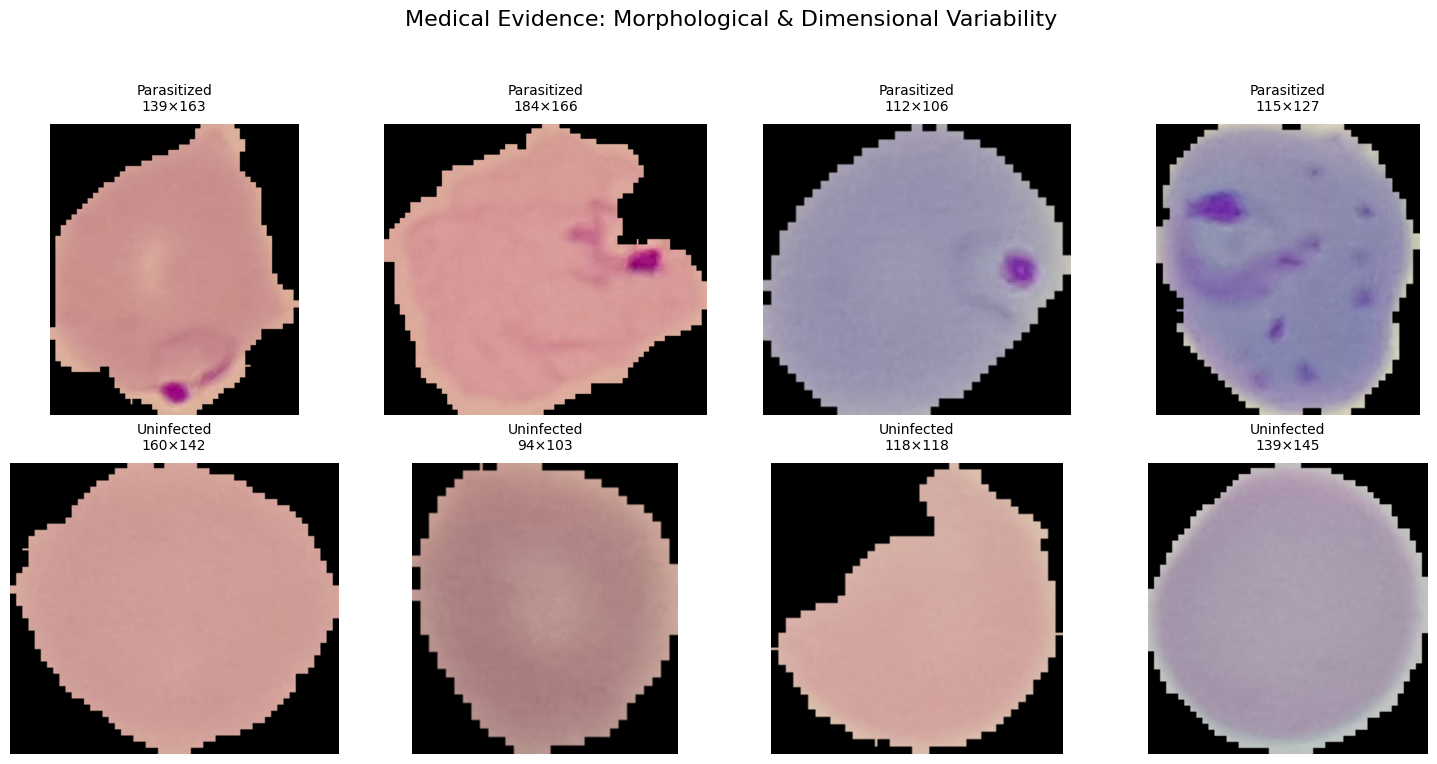

In [15]:
def plot_4_per_class_with_dims(base_path):
    categories = ['Parasitized', 'Uninfected']
    fig, axes = plt.subplots(2, 4, figsize=(15, 8))

    for i, category in enumerate(categories):
        folder_path = os.path.join(base_path, category)
        files = os.listdir(folder_path)

        # Safe sampling (avoids crash if <4 images)
        sample_names = random.sample(files, min(4, len(files)))

        for j, img_name in enumerate(sample_names):
            img_path = os.path.join(folder_path, img_name)
            img = cv2.imread(img_path)

            # Skip if image failed to load
            if img is None:
                continue

            h, w, _ = img.shape
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            ax = axes[i, j]
            ax.imshow(img)
            ax.set_title(f"{category}\n{w}×{h}", fontsize=10, pad=10)
            ax.axis('off')

    plt.suptitle("Medical Evidence: Morphological & Dimensional Variability", fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


# Run
plot_4_per_class_with_dims(base_path)


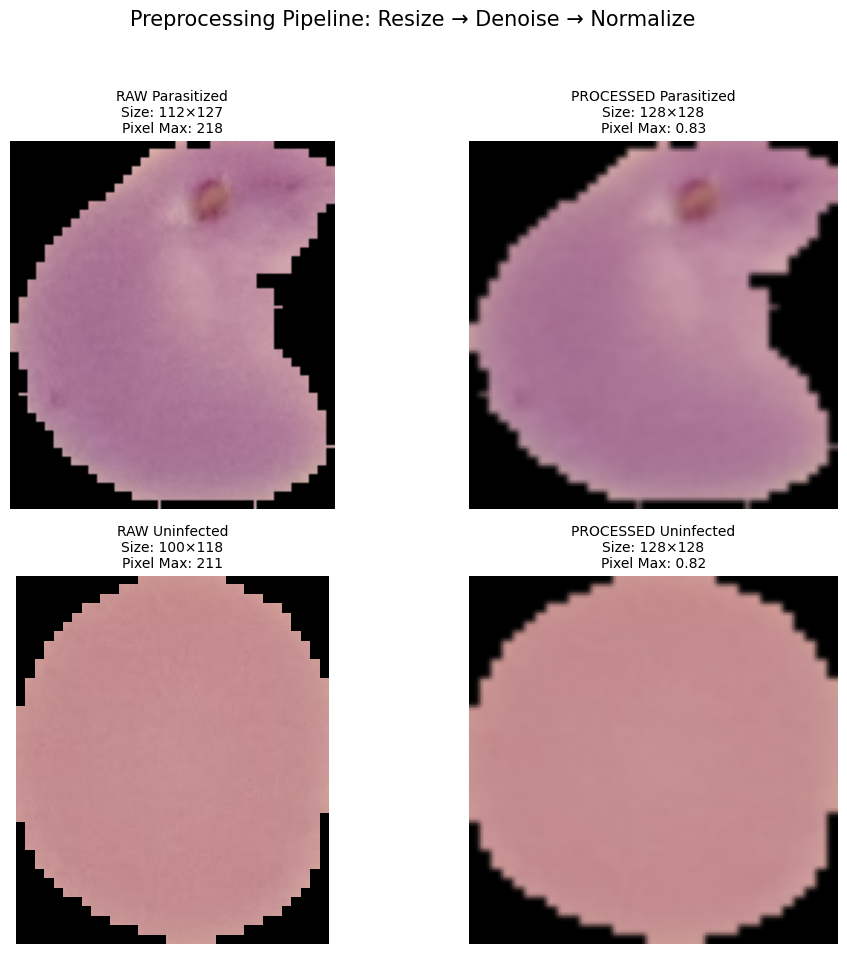

In [120]:
def complete_trio_preprocessing(image_path):
    # 1. Load & Color Correction
    img = cv2.imread(image_path)


    # Safety check
    if img is None:
        raise ValueError(f"Image not found or corrupted: {image_path}")


    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h_raw, w_raw, _ = img.shape


    # 2. RESIZE (Addressing Dimensional Variability)
    img_resized = cv2.resize(img, (128, 128))


    # 3. DENOISE (Addressing Image Noise with Gaussian Blur)
    img_denoised = cv2.GaussianBlur(img_resized, (3, 3), 0)


    # 4. NORMALIZE (Scaling pixels 0-255 to 0.0-1.0)
    # This is the critical step for CNN convergence
    img_final = img_denoised.astype('float32') / 255.0


    return img, img_final, w_raw, h_raw




def plot_final_preprocessing_proof(base_path):
    categories = ['Parasitized', 'Uninfected']
    fig, axes = plt.subplots(2, 2, figsize=(10, 10))


    for i, cat in enumerate(categories):
        folder = os.path.join(base_path, cat)
        files = os.listdir(folder)


        # Safe random selection
        img_name = random.choice(files)
        path = os.path.join(folder, img_name)


        raw, processed, w, h = complete_trio_preprocessing(path)


        # Display Raw
        axes[i, 0].imshow(raw)
        axes[i, 0].set_title(
            f"RAW {cat}\nSize: {w}×{h}\nPixel Max: {raw.max()}",
            fontsize=10
        )
        axes[i, 0].axis('off')


        # Display Processed
        axes[i, 1].imshow(processed)
        axes[i, 1].set_title(
            f"PROCESSED {cat}\nSize: 128×128\nPixel Max: {processed.max():.2f}",
            fontsize=10
        )
        axes[i, 1].axis('off')


    plt.suptitle("Preprocessing Pipeline: Resize → Denoise → Normalize", fontsize=15)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()




# Run
plot_final_preprocessing_proof(base_path)


In [46]:

# --- PREPROCESSING FUNCTION ---
def trio_denoise_step(image):
    # Convert to uint8 for OpenCV (0–255)
    img_uint8 = image.astype('uint8')

    # Mild Gaussian Blur (reduces noise)
    img_blurred = cv2.GaussianBlur(img_uint8, (3, 3), 0)

    # Normalize to [0,1]
    img_final = img_blurred.astype('float32') / 255.0

    return img_final


# --- DATA GENERATOR ---
datagen = ImageDataGenerator(
    preprocessing_function=trio_denoise_step,

    # Augmentationx
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,

    validation_split=0.2
)


# --- TRAINING SET ---
train_gen = datagen.flow_from_directory(
    base_path,
    target_size=(128, 128),
    batch_size=32,
    class_mode='binary',
    classes=['Parasitized', 'Uninfected'],
    shuffle=True,
    seed=SEED,
    subset='training'
)


# --- VALIDATION SET ---
val_gen = datagen.flow_from_directory(
    base_path,
    target_size=(128, 128),
    batch_size=32,
    class_mode='binary',
    classes=['Parasitized', 'Uninfected'],
    shuffle=False,
    seed=SEED,
    subset='validation'
)

Found 22048 images belonging to 2 classes.
Found 5510 images belonging to 2 classes.


In [26]:

#  MODEL + TRAINING
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks

# --- MODEL DESIGN ---
def build_final_cnn():
    model = models.Sequential([
        # 1. Input Layer
        layers.Input(shape=(128, 128, 3)),

        # 2. Feature Extraction
        # 3x3 filters capture small parasite patterns
        layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),                  # stabilizes training
        layers.MaxPooling2D((2, 2)),                  # reduces spatial size
        layers.Dropout(0.25),                         # prevents overfitting

        layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.3),                          # higher dropout in deeper layer

        # 3. Classification Head
        layers.GlobalAveragePooling2D(),              # reduces parameters (better than Flatten)

        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),

        # 4. Output Layer (Binary classification)
        layers.Dense(1, activation='sigmoid')
    ])

    # --- Compile Model ---
    model.compile(
        optimizer=optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model


# Initialize model
model = build_final_cnn()


# CALLBACKS
# Stop training early if validation loss doesn't improve
early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# Reduce learning rate when stuck
reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=2,
    min_lr=1e-5
)

# Save best model
checkpoint = callbacks.ModelCheckpoint(
    'best_model.keras',
    monitor='val_loss',
    save_best_only=True
)

#  TRAINING
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20,
    callbacks=[early_stop, reduce_lr, checkpoint],
    verbose=1
)

Epoch 1/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 1006s 1s/step - accuracy: 0.8154 - loss: 0.4272 - val_accuracy: 0.7510 - val_loss: 0.9851 - learning_rate: 0.0010
Epoch 2/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 1006s 1s/step - accuracy: 0.9234 - loss: 0.2359 - val_accuracy: 0.9156 - val_loss: 0.2721 - learning_rate: 0.0010
Epoch 3/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 975s 1s/step - accuracy: 0.9360 - loss: 0.2058 - val_accuracy: 0.9176 - val_loss: 0.2581 - learning_rate: 0.0010
Epoch 4/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 992s 1s/step - accuracy: 0.9398 - loss: 0.1921 - val_accuracy: 0.9214 - val_loss: 0.2501 - learning_rate: 0.0010
Epoch 5/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 991s 1s/step - accuracy: 0.9428 - loss: 0.1852 - val_accuracy: 0.9325 - val_loss: 0.1860 - learning_rate: 0.0010
Epoch 6/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 1004s 1s/step - accuracy: 0.9460 - loss: 0.1762 - val_accuracy: 0.8862 - val_loss: 0.3669 - learning_rate: 0.0010
Epoch 7/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 1007s 1s/step - accuracy: 0.9497 - loss

In [28]:
# Show model summary
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 332,485 (1.27 MB)

 Trainable params: 110,593 (432.00 KB)

 Non-trainable params: 704 (2.75 KB)

 Optimizer params: 221,188 (864.02 KB)

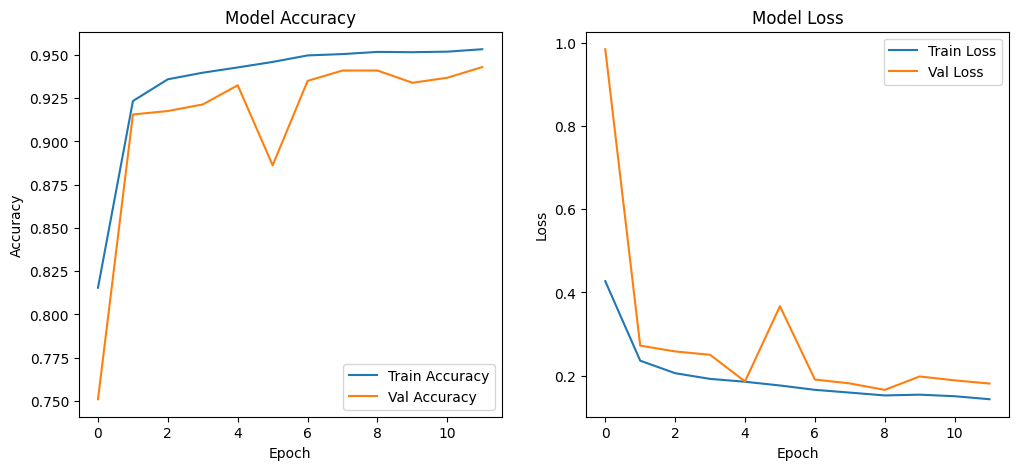

In [29]:
# Plot Accuracy & Loss
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

173/173 ━━━━━━━━━━━━━━━━━━━━ 56s 324ms/step


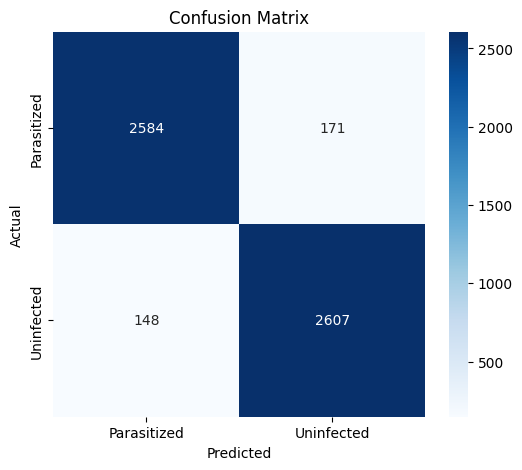

              precision    recall  f1-score   support

 Parasitized       0.95      0.94      0.94      2755
  Uninfected       0.94      0.95      0.94      2755

    accuracy                           0.94      5510
   macro avg       0.94      0.94      0.94      5510
weighted avg       0.94      0.94      0.94      5510



In [30]:
# Predictions
y_pred = model.predict(val_gen)
y_pred = (y_pred > 0.5).astype(int)

# True labels
y_true = val_gen.classes

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Parasitized', 'Uninfected'],
            yticklabels=['Parasitized', 'Uninfected'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Classification Report
print(classification_report(y_true, y_pred, target_names=['Parasitized', 'Uninfected']))

173/173 ━━━━━━━━━━━━━━━━━━━━ 55s 316ms/step


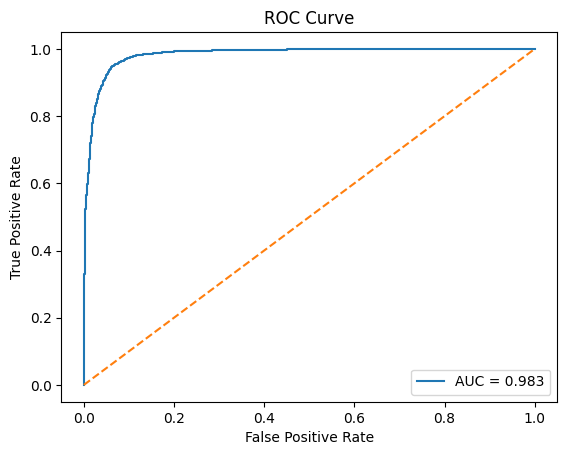

In [33]:
y_pred_prob = model.predict(val_gen)

fpr, tpr, _ = roc_curve(y_true, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [38]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Predictions
y_pred_prob = model.predict(val_gen).ravel()
y_pred = (y_pred_prob > 0.5).astype(int)

y_true = val_gen.classes

# Metrics
print("=== CLASSIFICATION REPORT ===")
print(classification_report(y_true, y_pred, target_names=["Parasitized", "Uninfected"]))

print("\n=== CONFUSION MATRIX ===")
print(confusion_matrix(y_true, y_pred))

# ROC AUC
roc_auc = roc_auc_score(y_true, y_pred_prob)
print("\n=== ROC AUC SCORE ===")
print("AUC:", roc_auc)

173/173 ━━━━━━━━━━━━━━━━━━━━ 65s 375ms/step
=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

 Parasitized       0.95      0.93      0.94      2755
  Uninfected       0.94      0.95      0.94      2755

    accuracy                           0.94      5510
   macro avg       0.94      0.94      0.94      5510
weighted avg       0.94      0.94      0.94      5510


=== CONFUSION MATRIX ===
[[2575  180]
 [ 143 2612]]

=== ROC AUC SCORE ===
AUC: 0.9842389188441407


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step


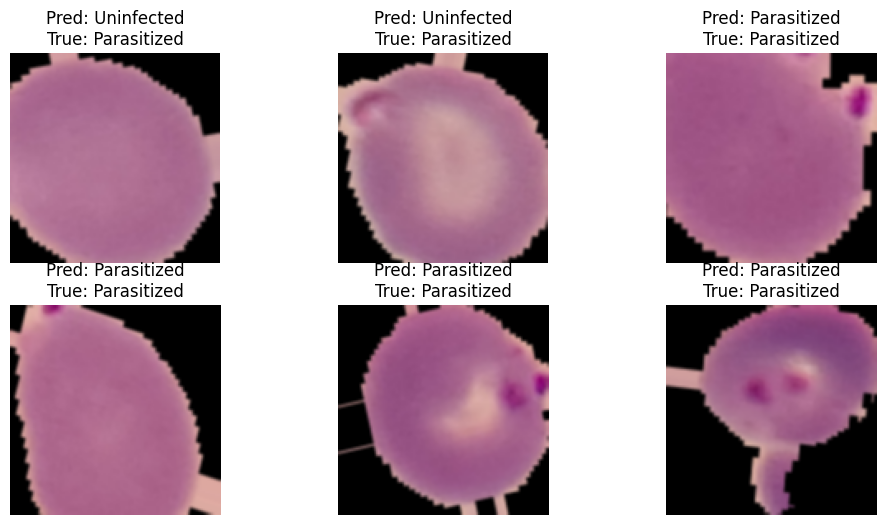

In [116]:
def show_predictions(generator, model, num_images=6):
    images, labels = next(generator)
    preds = model.predict(images)

    plt.figure(figsize=(12,6))

    for i in range(num_images):
        plt.subplot(2,3,i+1)
        plt.imshow(images[i])
        pred_label = "Uninfected" if preds[i] > 0.5 else "Parasitized"
        true_label = "Uninfected" if labels[i] == 1 else "Parasitized"

        plt.title(f"Pred: {pred_label}\nTrue: {true_label}")
        plt.axis('off')

    plt.show()

show_predictions(val_gen, model)

In [97]:
# Check your layer names
for i, layer in enumerate(model.layers):
    print(f"Index {i}: {layer.name} - {layer.__class__.__name__}")

# Use the index of the LAST Conv2D layer found above in your Grad-CAM function

Index 0: conv2d_3 - Conv2D
Index 1: batch_normalization_4 - BatchNormalization
Index 2: max_pooling2d_3 - MaxPooling2D
Index 3: dropout_4 - Dropout
Index 4: conv2d_4 - Conv2D
Index 5: batch_normalization_5 - BatchNormalization
Index 6: max_pooling2d_4 - MaxPooling2D
Index 7: dropout_5 - Dropout
Index 8: conv2d_5 - Conv2D
Index 9: batch_normalization_6 - BatchNormalization
Index 10: max_pooling2d_5 - MaxPooling2D
Index 11: dropout_6 - Dropout
Index 12: global_average_pooling2d_1 - GlobalAveragePooling2D
Index 13: dense_2 - Dense
Index 14: batch_normalization_7 - BatchNormalization
Index 15: dropout_7 - Dropout
Index 16: dense_3 - Dense


Using: /content/malaria_data/cell_images/Parasitized/C59P20thinF_IMG_20150803_113809_cell_5.png | Class: Parasitized


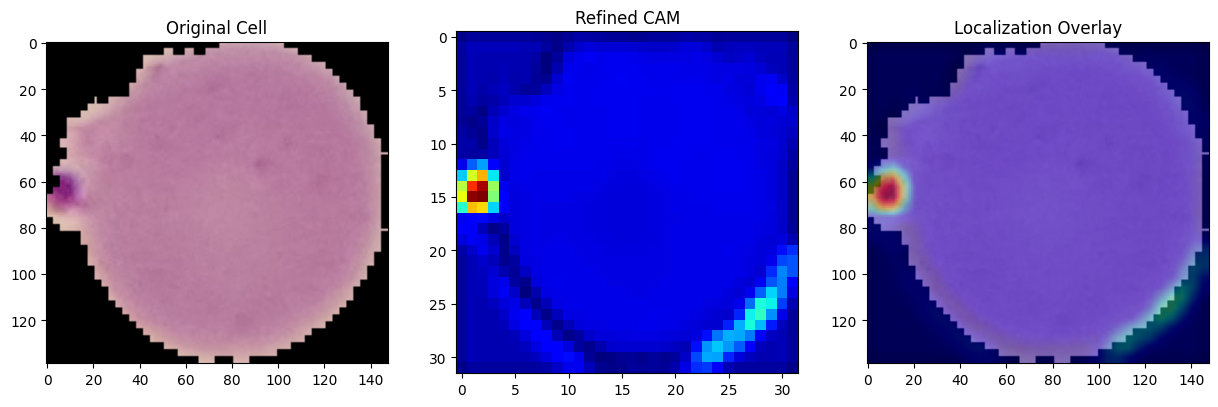

In [141]:
def get_high_contrast_cam(img_tensor, model):
    # 1. Extract feature maps (Index 8: conv2d_5)
    spatial_model = tf.keras.Model(model.inputs, model.get_layer("conv2d_5").output)
    features = spatial_model.predict(img_tensor, verbose=0)[0]

    # 2. Get weights from the Dense layer (Index 13: dense_2)
    # weights shape: (Input_Filters, Neurons) -> (128, 128)
    weights = model.get_layer("dense_2").get_weights()[0]

    # 3. Use the MAX weight for each filter across all neurons
    # instead of the mean. This finds the "strongest" feature detectors.
    weights_importance = np.max(weights, axis=1)

    # 4. Generate Heatmap
    cam = np.zeros(features.shape[0:2], dtype=np.float32)
    for i in range(len(weights_importance)):
        cam += weights_importance[i] * features[:, :, i]

    # 5. Robust Normalization
    cam = np.maximum(cam, 0) # Remove negative influence

    # Check if anything was caught
    if np.max(cam) > 1e-10:
        cam = cam / np.max(cam)
    else:
        # Fallback: Just show the raw sum of all activations
        print("Warning: No strong weights found. Showing raw activations.")
        cam = np.sum(features, axis=-1)
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-10)

    return cam

# --- RUN AND PLOT ---
img_path = get_random_image()
original, img_tensor = load_img(img_path)
heatmap = get_high_contrast_cam(img_tensor, model)

# Resize to original cell image dimensions
heatmap_resized = cv2.resize(heatmap, (original.shape[1], original.shape[0]))
heatmap_color = plt.cm.jet(heatmap_resized)[..., :3]
heatmap_color = np.uint8(heatmap_color * 255)
overlay = cv2.addWeighted(original, 0.6, heatmap_color, 0.4, 0)

plt.figure(figsize=(15, 5))
plt.subplot(131); plt.imshow(original); plt.title("Original Cell")
plt.subplot(132); plt.imshow(heatmap, cmap='jet'); plt.title("Refined CAM")
plt.subplot(133); plt.imshow(overlay); plt.title("Localization Overlay")
plt.show()

Using: /content/malaria_data/cell_images/Uninfected/C226ThinF_IMG_20151112_131408_cell_123.png | Class: Uninfected


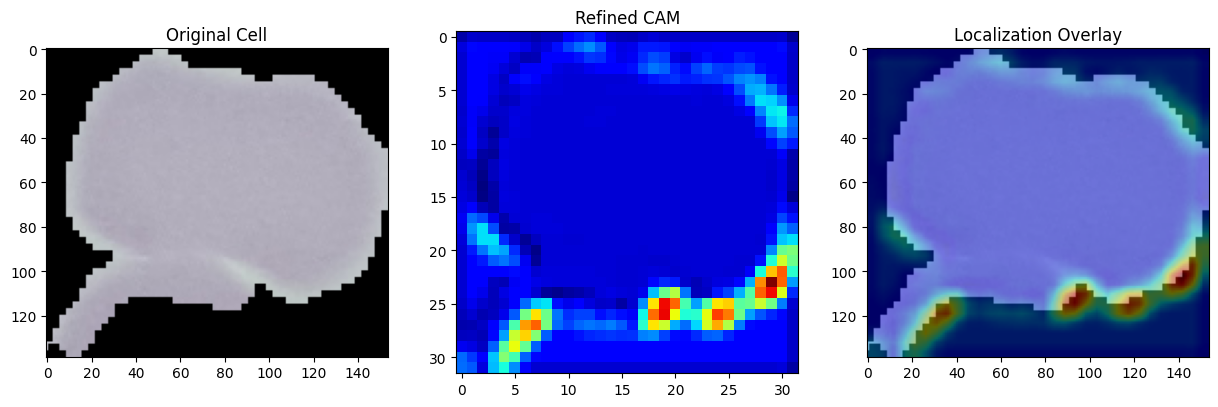

In [134]:
def get_high_contrast_cam(img_tensor, model):
    # 1. Extract feature maps (Index 8: conv2d_5)
    spatial_model = tf.keras.Model(model.inputs, model.get_layer("conv2d_5").output)
    features = spatial_model.predict(img_tensor, verbose=0)[0]

    # 2. Get weights from the Dense layer (Index 13: dense_2)
    # weights shape: (Input_Filters, Neurons) -> (128, 128)
    weights = model.get_layer("dense_2").get_weights()[0]

    # 3. Use the MAX weight for each filter across all neurons
    # instead of the mean. This finds the "strongest" feature detectors.
    weights_importance = np.max(weights, axis=1)

    # 4. Generate Heatmap
    cam = np.zeros(features.shape[0:2], dtype=np.float32)
    for i in range(len(weights_importance)):
        cam += weights_importance[i] * features[:, :, i]

    # 5. Robust Normalization
    cam = np.maximum(cam, 0) # Remove negative influence

    # Check if anything was caught
    if np.max(cam) > 1e-10:
        cam = cam / np.max(cam)
    else:
        # Fallback: Just show the raw sum of all activations
        print("Warning: No strong weights found. Showing raw activations.")
        cam = np.sum(features, axis=-1)
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-10)

    return cam

# --- RUN AND PLOT ---
img_path = get_random_image()
original, img_tensor = load_img(img_path)
heatmap = get_high_contrast_cam(img_tensor, model)

# Resize to original cell image dimensions
heatmap_resized = cv2.resize(heatmap, (original.shape[1], original.shape[0]))
heatmap_color = plt.cm.jet(heatmap_resized)[..., :3]
heatmap_color = np.uint8(heatmap_color * 255)
overlay = cv2.addWeighted(original, 0.6, heatmap_color, 0.4, 0)

plt.figure(figsize=(15, 5))
plt.subplot(131); plt.imshow(original); plt.title("Original Cell")
plt.subplot(132); plt.imshow(heatmap, cmap='jet'); plt.title("Refined CAM")
plt.subplot(133); plt.imshow(overlay); plt.title("Localization Overlay")
plt.show()

Using: /content/malaria_data/cell_images/Parasitized/C80P41ThinF_IMG_20150817_111802_cell_4.png | Class: Parasitized


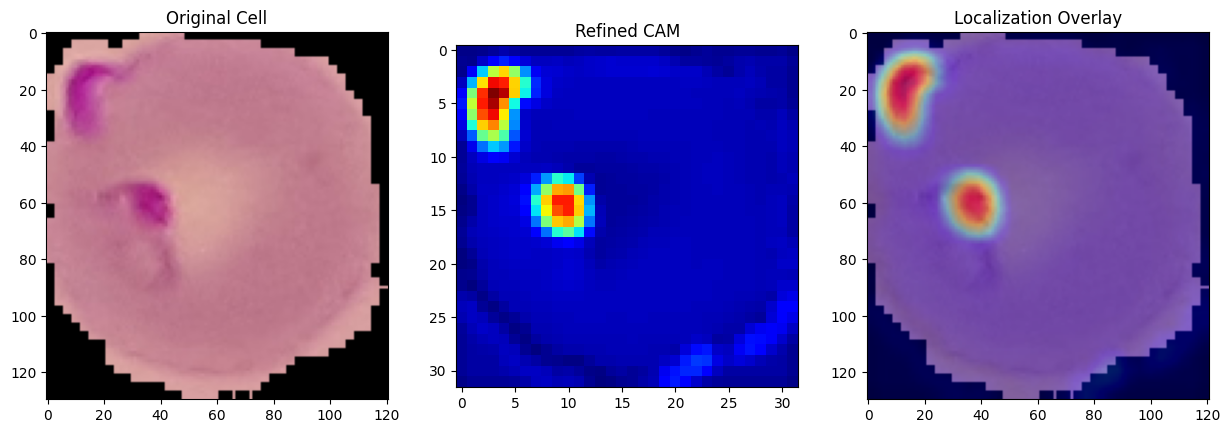

In [145]:
def get_high_contrast_cam(img_tensor, model):
    # 1. Extract feature maps (Index 8: conv2d_5)
    spatial_model = tf.keras.Model(model.inputs, model.get_layer("conv2d_5").output)
    features = spatial_model.predict(img_tensor, verbose=0)[0]

    # 2. Get weights from the Dense layer (Index 13: dense_2)
    # weights shape: (Input_Filters, Neurons) -> (128, 128)
    weights = model.get_layer("dense_2").get_weights()[0]

    # 3. Use the MAX weight for each filter across all neurons
    # instead of the mean. This finds the "strongest" feature detectors.
    weights_importance = np.max(weights, axis=1)

    # 4. Generate Heatmap
    cam = np.zeros(features.shape[0:2], dtype=np.float32)
    for i in range(len(weights_importance)):
        cam += weights_importance[i] * features[:, :, i]

    # 5. Robust Normalization
    cam = np.maximum(cam, 0) # Remove negative influence

    # Check if anything was caught
    if np.max(cam) > 1e-10:
        cam = cam / np.max(cam)
    else:
        # Fallback: Just show the raw sum of all activations
        print("Warning: No strong weights found. Showing raw activations.")
        cam = np.sum(features, axis=-1)
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-10)

    return cam

# --- RUN AND PLOT ---
img_path = get_random_image()
original, img_tensor = load_img(img_path)
heatmap = get_high_contrast_cam(img_tensor, model)

# Resize to original cell image dimensions
heatmap_resized = cv2.resize(heatmap, (original.shape[1], original.shape[0]))
heatmap_color = plt.cm.jet(heatmap_resized)[..., :3]
heatmap_color = np.uint8(heatmap_color * 255)
overlay = cv2.addWeighted(original, 0.6, heatmap_color, 0.4, 0)

plt.figure(figsize=(15, 5))
plt.subplot(131); plt.imshow(original); plt.title("Original Cell")
plt.subplot(132); plt.imshow(heatmap, cmap='jet'); plt.title("Refined CAM")
plt.subplot(133); plt.imshow(overlay); plt.title("Localization Overlay")
plt.show()